<a href="https://colab.research.google.com/github/liwiaflorkiwicz/EEG_dimensiality_reduction/blob/main/LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LDA for EEG dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# read file
data = pd.read_csv('/content/dataset_A_hands.csv', header = 0)
data.head()
#print(data.shape)

,FC5,FC3,FC1,FCz,FC2,FC4,FC6,C5,C3,C1,...,PO7,PO3,POz,PO4,PO8,O1,Oz,O2,Iz,Label
0,-11.368526,-11.424228,-11.585911,-11.587444,-11.516528,-11.458961,-11.326939,-11.408007,-11.629599,-11.656776,...,-11.226600,-11.357553,-11.381296,-11.238655,-11.062158,-11.126559,-11.223495,-11.151625,-10.948594,Task3
1,-11.284149,-11.422955,-11.369446,-11.320009,-11.390571,-11.411450,-11.411991,-11.402370,-11.569449,-11.696185,...,-10.981480,-11.025114,-11.026598,-11.063468,-11.030770,-10.868531,-10.866038,-10.920515,-10.739326,Task1
2,-11.431263,-11.430120,-11.482541,-11.534096,-11.495824,-11.367992,-11.330367,-11.383096,-11.557855,-11.698244,...,-10.891545,-11.036507,-11.060690,-10.976081,-10.770071,-10.759802,-10.705004,-10.659787,-10.439506,Task2
3,-11.446603,-11.464615,-11.413162,-11.382691,-11.351718,-11.438916,-11.399082,-11.362765,-11.628451,-11.667057,...,-10.949354,-11.032611,-11.052224,-10.937487,-10.974803,-10.871874,-10.841078,-10.876684,-10.661939,Task2
4,-11.467128,-11.599652,-11.588888,-11.570401,-11.589498,-11.433946,-11.456305,-11.366391,-11.675037,-11.676603,...,-11.082195,-11.126224,-11.142371,-11.117976,-10.992686,-10.988595,-11.030893,-11.036307,-10.890251,Task1


## LDA Algorithm

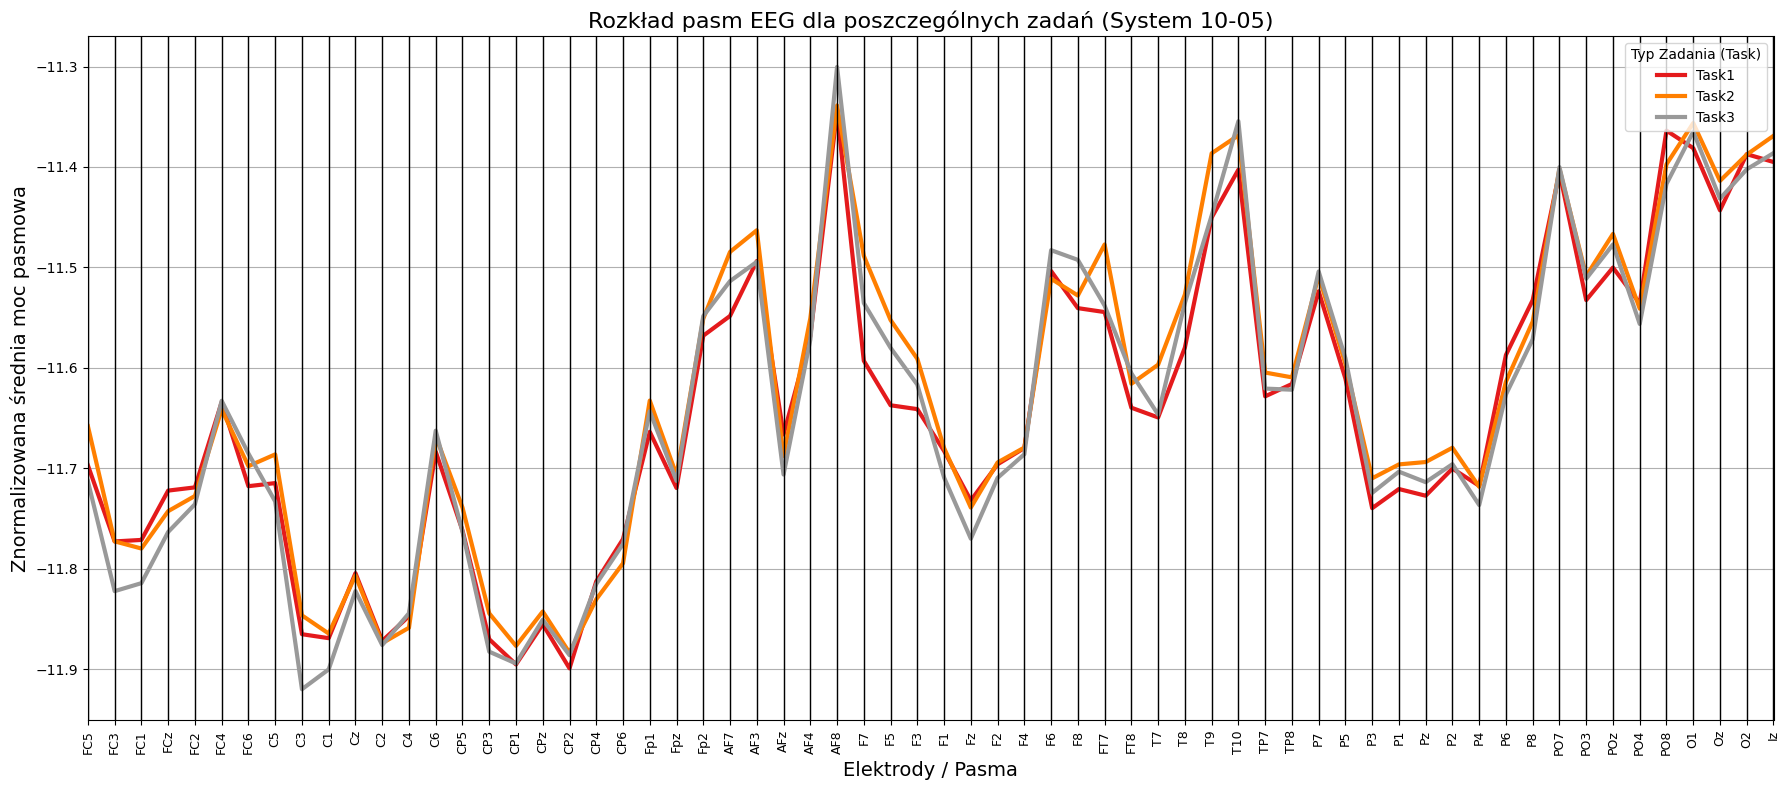

In [4]:
from pandas.plotting import parallel_coordinates

plt.figure(figsize=(18, 8))

# Wykres uśredniony dla zadań
df_mean = data.groupby('Label').mean().reset_index()
parallel_coordinates(df_mean, class_column='Label', colormap='Set1', linewidth=3.0)

plt.title('Rozkład pasm EEG dla poszczególnych zadań (System 10-05)', fontsize=16)
plt.xlabel('Elektrody / Pasma', fontsize=14)
plt.ylabel('Znormalizowana średnia moc pasmowa', fontsize=14)
plt.xticks(rotation=90, fontsize=9)

plt.legend(title='Typ Zadania (Task)', loc='upper right')

plt.tight_layout()
plt.show()

Visualization

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=['Label'])
y = data['Label']

# -- StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -- PCA Transformation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# PCA df
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Label'] = y.values

# -- LDA transformation
def plot_lda(shrinkage, solver):
  # LDA
  lda = LinearDiscriminantAnalysis(solver=solver, shrinkage=shrinkage)
  X_lda = lda.fit_transform(X_scaled, y)

  # LDA df
  df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
  df_lda['Label'] = y.values

  # -- Plotting
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))
  palette = ['#1f77b4', '#ff7f0e', '#2ca02c']

  # PCA
  sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Label', palette=palette,
                  ax=axes[0], s=80, alpha=0.8, edgecolor='k')
  axes[0].set_title('PRZED LDA: Redukcja PCA (brak nadzoru)', fontsize=14)
  axes[0].set_xlabel('PC1')
  axes[0].set_ylabel('PC2')
  axes[0].grid(True, alpha=0.3)

  # LDA
  sns.scatterplot(data=df_lda, x='LD1', y='LD2', hue='Label', palette=palette,
                  ax=axes[1], s=80, alpha=0.8, edgecolor='k')
  axes[1].set_title(f'PO LDA (Solver: {solver}, Shrinkage: {shrinkage})', fontsize=14)
  axes[1].set_xlabel('LD1')
  axes[1].set_ylabel('LD2')
  axes[1].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

In [20]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=['Label'])
y = data['Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

le = LabelEncoder()
y_num = le.fit_transform(y)

score_before = silhouette_score(X_scaled, y_num)

print(f"Silhouette przed LDA: {score_before:.4f}")

Silhouette przed LDA: -0.0051


Solver: svd    | Shrinkage: None  | Silhouette Score: 0.0494
Solver: eigen  | Shrinkage: auto  | Silhouette Score: 0.0328
Solver: eigen  | Shrinkage: 0.0   | Silhouette Score: 0.0494
Solver: eigen  | Shrinkage: 0.2   | Silhouette Score: 0.0216
Solver: eigen  | Shrinkage: 0.5   | Silhouette Score: 0.0056
Solver: eigen  | Shrinkage: 0.7   | Silhouette Score: -0.0076
Solver: eigen  | Shrinkage: 0.9   | Silhouette Score: -0.0295
--------------------------------------------------
Najlepiej rozdzielone dane dają parametry: {'solver': 'eigen', 'shrinkage': 0.0} (Score: 0.0494)


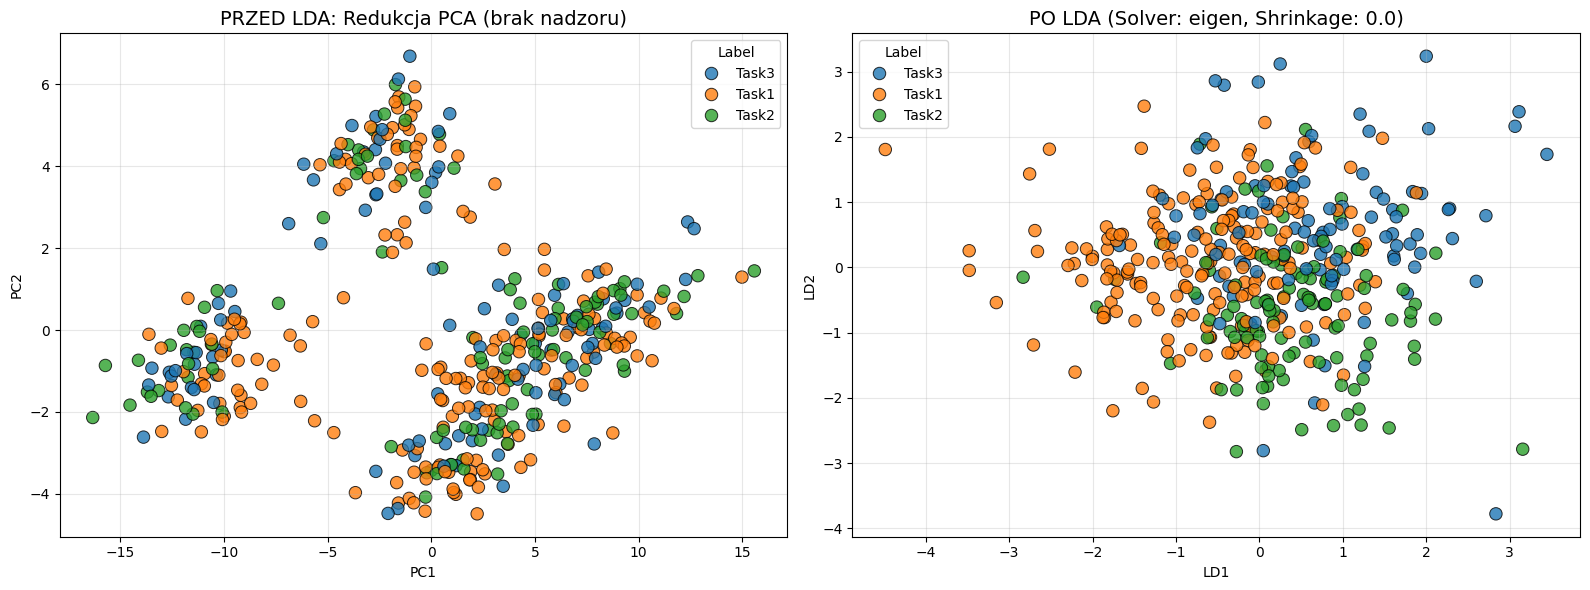

In [21]:
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import silhouette_score

solvers = ['svd', 'eigen']
shrinkages = ['auto', 0.0, 0.2, 0.5, 0.7, 0.9]

best_score = -1
best_params = {}

for solver in solvers:
    current_shrinkages = [None] if solver == 'svd' else shrinkages

    for shrink in current_shrinkages:
        try:
            lda = LinearDiscriminantAnalysis(solver=solver, shrinkage=shrink)
            X_lda_reduced = lda.fit_transform(X_scaled, y)

            score = silhouette_score(X_lda_reduced, y)

            print(f"Solver: {solver:<6} | Shrinkage: {str(shrink):<5} | Silhouette Score: {score:.4f}")

            if score > best_score:
                best_score = score
                best_params = {'solver': solver, 'shrinkage': shrink}

        except Exception as e:
            pass

print("-" * 50)
print(f"Najlepiej rozdzielone dane dają parametry: {best_params} (Score: {best_score:.4f})")

plot_lda(shrinkage=best_params['shrinkage'], solver=best_params['solver'])

Explained Variance Ratio

Suma: 0.9999999999998299
LD1: 63.94%
LD2: 36.06%


/tmp/ipykernel_13136/3770566109.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


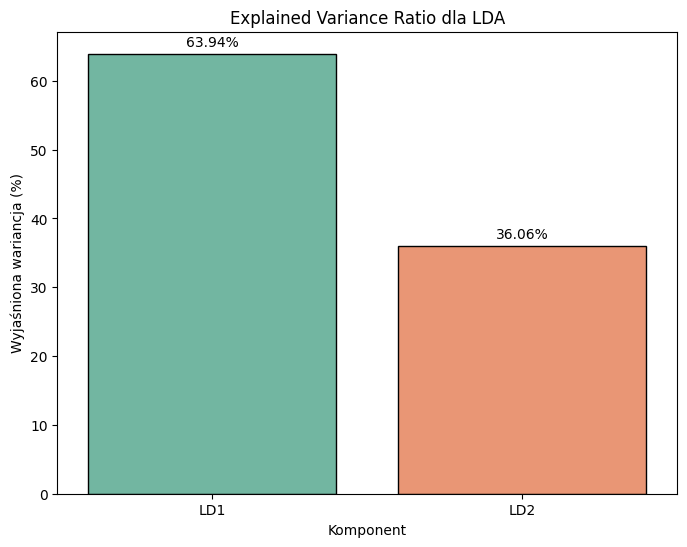

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

n_classes = len(np.unique(y))
n_components = min(X.shape[1], n_classes - 1)

lda = LinearDiscriminantAnalysis(
    solver='eigen',
    shrinkage=0.0,
    n_components=n_components
)

X_lda = lda.fit_transform(X_scaled, y)

explained_var = lda.explained_variance_ratio_

print("Suma:", explained_var.sum())

for i, var in enumerate(explained_var):
    print(f"LD{i+1}: {var*100:.2f}%")

df_var = pd.DataFrame({
    'Komponent': [f'LD{i+1}' for i in range(len(explained_var))],
    'Wyjaśniona wariancja (%)': explained_var * 100
})

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=df_var,
    x='Komponent',
    y='Wyjaśniona wariancja (%)',
    palette='Set2',
    edgecolor='black'
)

for i, v in enumerate(df_var['Wyjaśniona wariancja (%)']):
    ax.text(
        i,
        v + 1,
        f'{v:.2f}%',
        ha='center'
    )

plt.title('Explained Variance Ratio dla LDA')
plt.show()

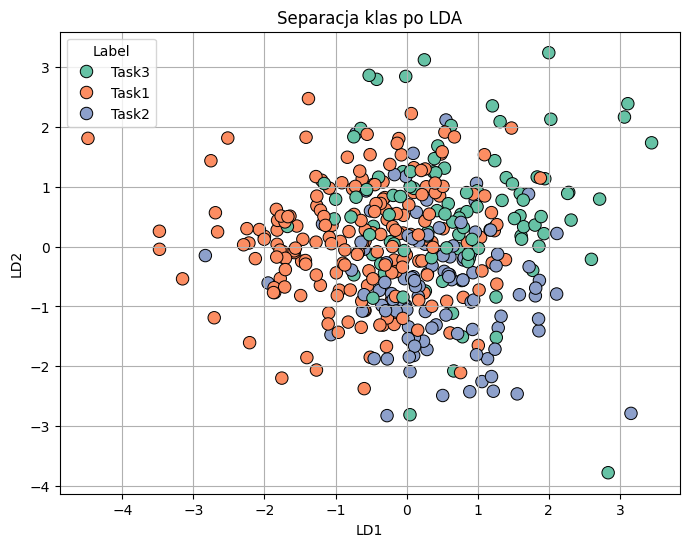

In [24]:
lda_df = pd.DataFrame(
    X_lda[:, :2],
    columns=['LD1', 'LD2']
)

lda_df['Label'] = y.values

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=lda_df,
    x='LD1',
    y='LD2',
    hue='Label',
    s=80,
    palette='Set2',
    edgecolor='black'
)

plt.title('Separacja klas po LDA')
plt.grid(True)
plt.show()

KDE plot

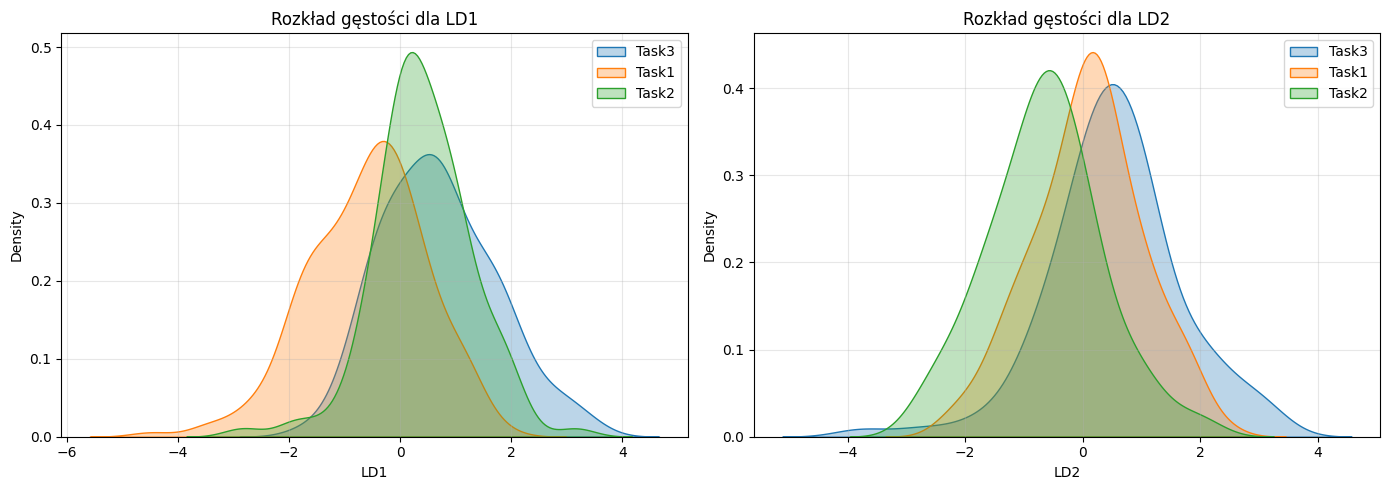

In [26]:
lda_df = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
lda_df['Label'] = y.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LD1
for cls in lda_df['Label'].unique():
    sns.kdeplot(
        data=lda_df[lda_df['Label'] == cls],
        x='LD1',
        fill=True,
        alpha=0.3,
        label=cls,
        ax=axes[0]
    )

axes[0].set_title('Rozkład gęstości dla LD1')
axes[0].set_xlabel('LD1')
axes[0].grid(alpha=0.3)
axes[0].legend()

# LD2
for cls in lda_df['Label'].unique():
    sns.kdeplot(
        data=lda_df[lda_df['Label'] == cls],
        x='LD2',
        fill=True,
        alpha=0.3,
        label=cls,
        ax=axes[1]
    )

axes[1].set_title('Rozkład gęstości dla LD2')
axes[1].set_xlabel('LD2')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

test statystyczny

In [28]:
from scipy.stats import f_oneway

for feature in ['LD1', 'LD2']:

    groups = [
        lda_df[lda_df['Label'] == cls][feature]
        for cls in lda_df['Label'].unique()
    ]

    F, p = f_oneway(*groups)

    print(f"\n{feature}")
    print(f"F-statistic = {F:.4f}")
    print(f"p-value = {p:.8f}")


LD1
F-statistic = 68.8068
p-value = 0.00000000

LD2
F-statistic = 38.7995
p-value = 0.00000000


wspólny rozkład klas w przestrzeni LDA



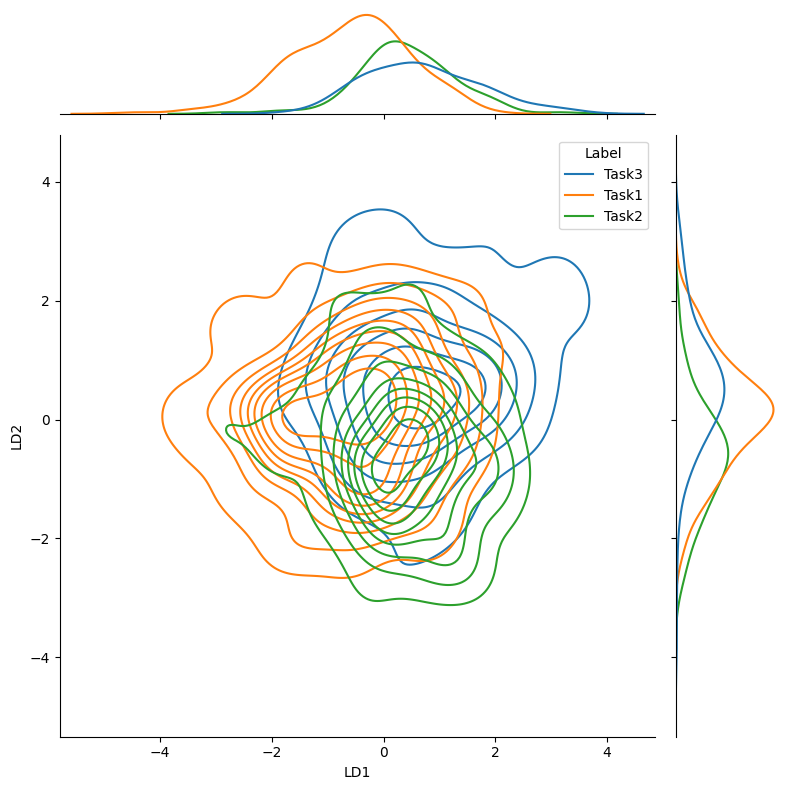

In [29]:
sns.jointplot(
    data=lda_df,
    x='LD1',
    y='LD2',
    hue='Label',
    kind='kde',
    height=8
)
plt.show()

### extras
LDA as a classificator

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = data.drop(columns=['Label'])
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda.fit(X_train_scaled, y_train)
y_pred = lda.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.41346153846153844

Classification Report:
              precision    recall  f1-score   support

       Task1       0.52      0.63      0.57        49
       Task2       0.29      0.21      0.24        28
       Task3       0.26      0.22      0.24        27

    accuracy                           0.41       104
   macro avg       0.35      0.36      0.35       104
weighted avg       0.39      0.41      0.40       104

